In [1]:
import os

script_path = "../src/preprocess.py"

if os.path.exists(script_path):
    print("✅ preprocess.py found!")
else:
    print("❌ File not found — check src/ folder")

✅ preprocess.py found!


In [2]:
# This runs the entire preprocess.py script
%run ../src/preprocess.py


🚀 Starting Phase 3: Tokenization & Sequence Engineering

STEP 3.1 — Building CAN ID Vocabulary
📖 Scanning all CAN IDs from dataset...
  Scanned 5,000,000 rows — 35 unique IDs found so far...
  Scanned 10,000,000 rows — 35 unique IDs found so far...
  Scanned 15,000,000 rows — 35 unique IDs found so far...
  Scanned 20,000,000 rows — 35 unique IDs found so far...
  Scanned 25,000,000 rows — 35 unique IDs found so far...
  Scanned 30,000,000 rows — 35 unique IDs found so far...
  Scanned 35,000,000 rows — 35 unique IDs found so far...
  Scanned 40,000,000 rows — 35 unique IDs found so far...
  Scanned 45,000,000 rows — 35 unique IDs found so far...
  Scanned 50,000,000 rows — 35 unique IDs found so far...
  Scanned 55,000,000 rows — 35 unique IDs found so far...

✅ Scan complete!
📊 Total unique CAN IDs found: 35
📋 Vocabulary size: 38 entries
   → [PAD]  = 0
   → [MASK] = 1
   → [UNK]  = 2
   → CAN IDs = 3 to 37

💾 Saved vocab.json → C:\Users\Rushikesh\PROJECTS\can_bus_ids_project\data\v

In [3]:
import json

with open("../data/vocab.json", "r") as f:
    vocab = json.load(f)

print(f"✅ vocab.json loaded!")
print(f"📋 Total vocab size : {len(vocab)}")
print(f"\nSpecial tokens:")
print(f"  [PAD]  → {vocab['[PAD]']}")
print(f"  [MASK] → {vocab['[MASK]']}")
print(f"  [UNK]  → {vocab['[UNK]']}")
print(f"\nSample CAN ID mappings:")
# Show first 10 real CAN IDs
count = 0
for key, val in vocab.items():
    if key not in ['[PAD]', '[MASK]', '[UNK]']:
        print(f"  {key} → {val}")
        count += 1
        if count >= 10:
            break

✅ vocab.json loaded!
📋 Total vocab size : 38

Special tokens:
  [PAD]  → 0
  [MASK] → 1
  [UNK]  → 2

Sample CAN ID mappings:
  0002 → 3
  00a0 → 4
  00a1 → 5
  0105 → 6
  0130 → 7
  0131 → 8
  0140 → 9
  0153 → 10
  018f → 11
  01f1 → 12


In [4]:
import torch

tensor = torch.load("../data/sequences.pt")

print(f"✅ sequences.pt loaded!")
print(f"📐 Tensor shape  : {tensor.shape}")
print(f"   → Rows        : {tensor.shape[0]:,} sequences")
print(f"   → Columns     : {tensor.shape[1]} tokens per sequence")
print(f"\n🔢 Sample sequence (first row):")
print(tensor[0])
print(f"\n🔢 Sample sequence (second row):")
print(tensor[1])

✅ sequences.pt loaded!
📐 Tensor shape  : torch.Size([500000, 64])
   → Rows        : 500,000 sequences
   → Columns     : 64 tokens per sequence

🔢 Sample sequence (first row):
tensor([16, 11, 13, 14, 17, 25,  3, 10, 15,  7,  8,  9, 18, 21, 19, 22, 16, 11,
        13, 14, 17, 24, 25, 20, 23, 12, 10,  3, 15, 18,  7,  8,  9, 19, 21, 22,
        11, 13, 14, 16, 17, 25,  3, 10, 15,  7,  8,  9, 18, 21, 19,  4,  5, 22,
        16, 11, 13, 14, 17, 24, 25, 20, 23, 12])

🔢 Sample sequence (second row):
tensor([ 9, 19, 21, 22, 11, 13, 14, 16, 17, 25,  3, 10, 15,  7,  8,  9, 18, 21,
        19,  4,  5, 22, 16, 11, 13, 14, 17, 24, 25, 20, 23, 12, 10,  3, 15, 18,
         7,  8,  9, 19, 21, 22, 16, 11, 13, 14, 17, 25,  3, 10, 15,  7,  8,  9,
        18, 21, 19, 22, 16, 11, 13, 14, 17, 24])


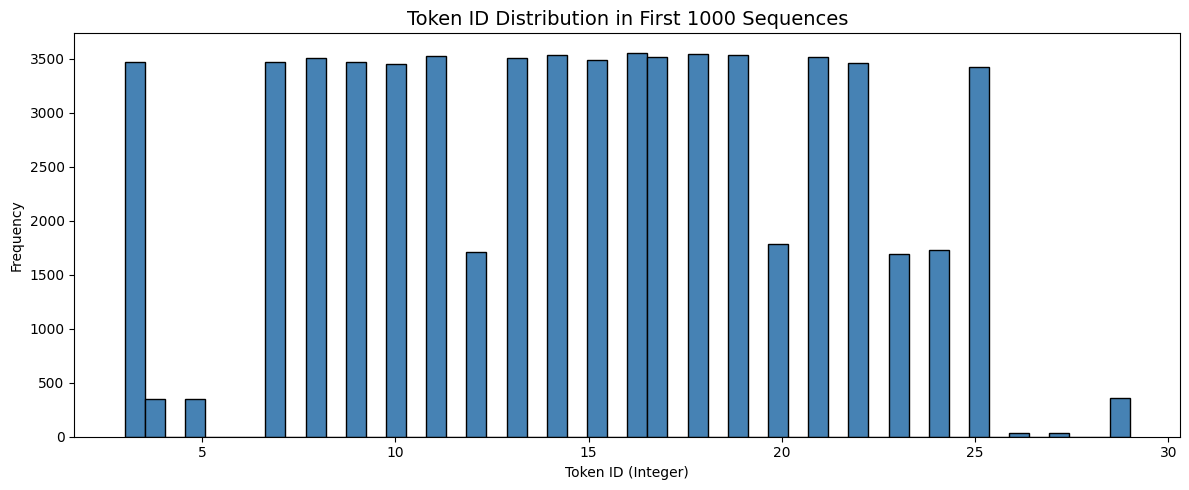

✅ Chart saved!


In [5]:
import matplotlib.pyplot as plt
import json

with open("../data/vocab.json", "r") as f:
    vocab = json.load(f)

# Plot token ID distribution in first 1000 sequences
tensor_sample = tensor[:1000].numpy().flatten()

plt.figure(figsize=(12, 5))
plt.hist(tensor_sample, bins=50, color='steelblue', edgecolor='black')
plt.title('Token ID Distribution in First 1000 Sequences', fontsize=14)
plt.xlabel('Token ID (Integer)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../data/token_distribution.png')
plt.show()
print("✅ Chart saved!")

phase 4 cells

In [6]:
import os

if os.path.exists("../src/dataset.py"):
    print("✅ dataset.py found!")
else:
    print("❌ Not found — check src/ folder")

✅ dataset.py found!


In [7]:
%run ../src/dataset.py


🚀 Phase 4: Testing MLM Dataset

📖 Loading vocabulary...
  ✅ Vocab size: 38
📦 Loading sequences tensor...
  ✅ Sequences loaded: 500,000
  ✅ Sequence length : 64

--- Testing single sample ---
input_ids shape      : torch.Size([64])
attention_mask shape : torch.Size([64])
labels shape         : torch.Size([64])

--- Masking visualization ---
Position   Original     Masked       Label     
---------------------------------------------
0          16           16           -100      
1          11           1            11         ← MASKED
2          13           13           -100      
3          14           1            14         ← MASKED
4          17           17           -100      
5          25           25           -100      
6          3            3            -100      
7          10           10           -100      
8          15           15           -100      
9          7            1            7          ← MASKED
10         8            8            -100      
11      

c:\Users\Rushikesh\PROJECTS\can_bus_ids_project\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


📖 Loading vocabulary...
  ✅ Vocab size: 38
📦 Loading sequences tensor...
  ✅ Sequences loaded: 500,000
  ✅ Sequence length : 64


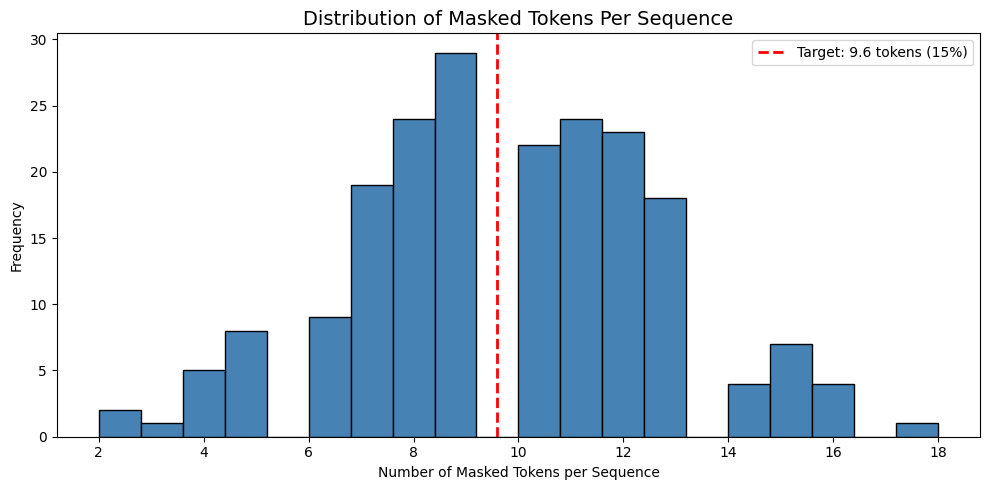

✅ Chart saved!
Average masked per sequence : 9.7
Target masked per sequence  : 9.6


In [8]:
import torch
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from dataset import CANBusMLMDataset

dataset = CANBusMLMDataset()

# Collect masking positions across 200 samples
mask_counts = []
for i in range(200):
    sample = dataset[i]
    labels = sample['labels']
    num_masked = (labels != -100).sum().item()
    mask_counts.append(num_masked)

plt.figure(figsize=(10, 5))
plt.hist(mask_counts, bins=20, color='steelblue', edgecolor='black')
plt.axvline(
    x=64*0.15, color='red',
    linestyle='--', linewidth=2,
    label=f'Target: {64*0.15:.1f} tokens (15%)'
)
plt.title('Distribution of Masked Tokens Per Sequence', fontsize=14)
plt.xlabel('Number of Masked Tokens per Sequence')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../data/masking_distribution.png')
plt.show()

print(f"✅ Chart saved!")
print(f"Average masked per sequence : {sum(mask_counts)/len(mask_counts):.1f}")
print(f"Target masked per sequence  : {64*0.15:.1f}")

In [9]:
from dataset import build_dataloaders

train_loader, val_loader, vocab_size = build_dataloaders(batch_size=64)

# Check one batch
batch = next(iter(train_loader))

print("=== BATCH VERIFICATION ===")
print(f"input_ids shape      : {batch['input_ids'].shape}")
print(f"attention_mask shape : {batch['attention_mask'].shape}")
print(f"labels shape         : {batch['labels'].shape}")

print(f"\n=== TOKEN CHECK ===")
print(f"Min token ID in batch : {batch['input_ids'].min().item()}")
print(f"Max token ID in batch : {batch['input_ids'].max().item()}")
print(f"Vocab size            : {vocab_size}")

print(f"\n=== LABEL CHECK ===")
labels_flat = batch['labels'].flatten()
active      = labels_flat[labels_flat != -100]
print(f"Total label positions  : {len(labels_flat):,}")
print(f"Active (masked) labels : {len(active):,}")
print(f"Ignored (-100) labels  : {(labels_flat == -100).sum().item():,}")
print(f"Actual mask rate       : {len(active)/len(labels_flat)*100:.1f}%")

print(f"\n✅ Everything looks correct!")
print(f"✅ Ready for Phase 5 — Model Training!")


Building DataLoaders...
📖 Loading vocabulary...
  ✅ Vocab size: 38
📦 Loading sequences tensor...
  ✅ Sequences loaded: 500,000
  ✅ Sequence length : 64

📊 Dataset split:
   Total      : 500,000
   Train      : 450,000 (90%)
   Validation : 50,000 (10%)

   Train batches : 7,032
   Val batches   : 782
   Batch size    : 64

✅ DataLoaders ready!
=== BATCH VERIFICATION ===
input_ids shape      : torch.Size([64, 64])
attention_mask shape : torch.Size([64, 64])
labels shape         : torch.Size([64, 64])

=== TOKEN CHECK ===
Min token ID in batch : 1
Max token ID in batch : 37
Vocab size            : 38

=== LABEL CHECK ===
Total label positions  : 4,096
Active (masked) labels : 586
Ignored (-100) labels  : 3,510
Actual mask rate       : 14.3%

✅ Everything looks correct!
✅ Ready for Phase 5 — Model Training!
